In [1]:
# step 1: Mount the drive first
from google.colab import drive
drive.mount("/content/drive/")

# step 2: Add the path of virtual environment (colab_env) site-packages
# to colaboratory system path
import sys
sys.path.append("/content/drive/MyDrive/MISY436/misy_436_base/lib/python3.12/site-packages")


# step 3: Add the path to your course folder
import os
os.chdir('/content/drive/MyDrive/MISY436')

Mounted at /content/drive/


# Exercise 3: BERTopic (25 pts)

## Name: YOUR_NAME

We will apply BERTopic to the SEC Letters Corpus.

Create a <font color = red> SHORTCUT </font> to the following file in your Folder for the Course. DO NOT attempt to download!

[Link to data set](https://drive.google.com/file/d/1NLbQFT0KW7GPfZh36Ez-S4kJffLU8HPo/view?usp=sharing)
- Open the link above
- File > Create Shortcut in Drive
- Move the shortcut to your folder for the course


This exercise must be sumbitted to Canvas by the end of class.

Remember to:
- **Share** the file with: jaredws@udel.edu & bonyy@udel.edu
- Export and submit the PDF version to Canvas
- Comment the Shared link to your `PDF` submission.

In [2]:
import polars as pl
from polars import col

df = pl.read_ipc("sec_letters_extracted.feather")
df.head()

file_name,letter_head,headings,paragraph_text
str,str,str,str
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""(intro)""","""We have reviewed your filing a…"
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""Appendix: Road Show Presentati…","""9. We note your disclosure on …"
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""General""","""1. We continue to evaluate you…"
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""Item 15, Recent Sales of Unreg…","""10. We note the new disclosure…"
"""2005-12-06 05_00_00_0001097503…","""Mail Stop 3561 November 16, 20…","""Legal Branch Chief""","""cc: via facsimile (212) 841-10…"


In [3]:
## What's in a File Name?
(
    df
    .select(col.file_name)
    .head(1)
    .item()
)## date-time the letters's upload, cik code of the company

'2005-12-06 05_00_00_0001097503.pdf'

In [20]:
## Let's create columns for the Filing Date, Year, and CIK (all in the file_name)
## filing year, and CIK (all in the file_name)
df = (
    df
    .with_columns(Filing_Date = col.file_name.str.slice(0,10).str.to_date())
    .with_columns(Filing_Year = col.Filing_Date.dt.year(),
                  CIK = col.file_name.str.split("_").list.get(-1).str.replace(".pdf", '').cast(pl.Int64))
)

In [23]:
## How many letters are we seeing each year?
(
    df
    .group_by('Filing_Year')
    .agg(col.file_name.n_unique())
    .sort(col.Filing_Year, descending = False)

)

Filing_Year,file_name
i32,u32
2005,3
2006,233
2007,352
2008,81
2009,173
…,…
2016,234
2017,362
2018,398


## Preprocessing

Unlike LDA, we don't NEED to preprocess the text for BERT; we WANT to encode the sentence endings and beginings.

We should still be cautious what text actually reaches the model; we don't want to train a model looking at the Postal Addresses of these letters.

In [29]:
## What sections (headings) should we ignore?
(
    df
    .group_by(col.headings)
    .agg(heading_count = col.file_name.n_unique())
    .sort(col.heading_count, descending = True)
)

headings,heading_count
str,u32
"""(intro)""",5333
"""Sincerely,""",5126
"""Assistant Director""",2827
"""General""",2080
"""Division of Corporation Financ…",1084
…,…
"""business. However, in accordan…",1
"""Form F-1""",1
"""Note 11 – Subsequent Events, p…",1


In [33]:
## Now, let's aggregate all the paragraph_text for each filing together,
#  if its in any other heading besides those we will ignore.
# for each leter together

df_agg = (
    df
    .filter(col.headings != '(intro)',
            col.headings != 'Sincerely,')
    .group_by(col.file_name) #group letters together
    .agg(body_text = col.paragraph_text.str.join(" ")) #Agg the paragraph_text together
)

In [39]:
## We're not done yet!
## How long are some of these letters now?
(
    df_agg
    .with_columns(char_length = col.body_text.str.len_chars())
    # We want a minimum size; start with 100
    .filter(col.char_length > 100)
    .select(col.char_length)
    .describe()
    #.transpose()
)


statistic,char_length
str,f64
"""count""",5253.0
"""null_count""",0.0
"""mean""",6734.084333
"""std""",7153.478895
"""min""",102.0
"""25%""",2077.0
"""50%""",4079.0
"""75%""",8560.0
"""max""",63852.0


In [49]:
## For the sake of time in class,
## Let's limit to only those IPOs in 2018-2020 (2006-2020)
import textwrap

## Create a Data frame as described above
## put all of my filtering in one step
#Agg the paragraph_text together

df_content = (
    df
    .filter(col.headings != '(intro)',
            col.headings != 'Sincerely,',
            col.Filing_Year >= 2018)
    .group_by(col.file_name) #group letters together
    .agg(body_text = col.paragraph_text.str.join(" "))
    .with_columns(char_length = col.body_text.str.len_chars())
    .filter(col.char_length > 100)
)

# Extract the text column to a list
text = df_content.select(col.body_text).to_series().to_list()


    ## THEN pull out just its text column.

print(textwrap.fill(text[0], 100))

 Please revise page F-25 to disclose the correct calculation of pro forma weighted-average 8. shares
outstanding – diluted. In this regard, the reconciliation does not appear to include pro forma
weighted-average shares outstanding – basic. Office of Technology cc: Nicolas Dumont    PubMatic,
Inc. Comapany NamePubMatic, Inc. October 13, 2020 OPacgtoeb 2er 13, 2020 Page 2 PubMatic, Inc.
Comapany NamePubMatic, Inc. October 13, 2020 OPacgtoeb 3er 13, 2020 Page 3 Please supplementally
provide us with copies of all written communications, as defined 9. in Rule 405 under the Securities
Act, that you, or anyone authorized to do so on your behalf, present to potential investors in
reliance on Section 5(d) of the Securities Act, whether or not they retain copies of the
communications. You may contact Frank Knapp, Staff Accountant, at (202) 551-3805 or Christine Dietz,
Senior Staff Accountant, at (202) 551-3408 if you have questions regarding comments on the Please
provide us with a breakdown of

## BERTopic


[Documentation](https://maartengr.github.io/BERTopic/index.html#quick-start)

In [24]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.6 MB/s eta 0:00:00


KeyboardInterrupt: 

In [25]:
# 3. Initialize the BERTopic model.
## Import alone may take some time ... ~ 12 minutes
## This is (mostly) an issue localized to Colab
import pickle as pk
from tqdm.auto import tqdm

from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer

## Train BERTopic Models

AND SAVE

In [50]:
# We set verbose=True to see the training progress.
# This takes Default Values for all other inputs. There are several we

# Step 1 - Retrieve embeddings
## This is a pretrained Word Embedding Model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Step 2 - Reduce dimensionality
## Reduce the high dimension of the word embedding vectors
## 2018# 10, 10, 0.1
## 2006# 15, 10, 0.1
umap_model = UMAP(n_neighbors=15, # Lower=Local; Larger=Global
                  n_components=10, # Dimensions we reduce to; 5-10 tends to work well for complex topics
                  min_dist=0.1,   # 0 is common to keep points close together, but may generalize poorly
                  metric='cosine', random_state = 42)

# Step 3 - Cluster reduced embeddings
## This is the part that (most greatly) modifies how many topis we will likely see
## min_cluster_size is the minimum number of UMAP observations to create a cluster
## HDBSCAN will result in a number of clusters, but it's not a predetermiend number.
## TUNING this paramter is CHALLENGING - we RARELY know how many topics we expect to see
## We Tend to prefer to see what topics are extracted and if they make sense;
## then investigate what they mean
## 2018: 10
## 2006: 20
hdbscan_model = HDBSCAN(min_cluster_size=10,## Higher=Fewer topics; minimum number of documents in each cluster
                        metric='euclidean', cluster_selection_method='eom', prediction_data=True)


### Step1-3 Creates the Topics!
### Steps4-6 Creates their representation that we can observe.


# Step 4 - Tokenize topics
## 2018: 0.04, 0.90
## 2006: 0.01, 0.95
# What words would represent these topics?
vectorizer_model = CountVectorizer(min_df = 0.04,
                                   max_df = 0.90,
                                   stop_words="english")

# Step 5 - Create topic representation
ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional) Fine-tune topic representations with
# a `bertopic.representation` model
representation_model = None # KeyBERTInspired


##
# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,           # Step 1 - Extract embeddings
  umap_model=umap_model,                     # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,               # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,         # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                 # Step 5 - Extract topic words
  representation_model=None,                 # Step 6 - (Optional) Fine-tune topic representations
  calculate_probabilities = True,            # We want the probabilities of each document belonging to each topic
  verbose = True,                             # Show progress during training

)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [51]:
# Train the BERTopic model
## ~2 minutes on 2018, 2019, 2020: 12 topics
## ~9 minutes on >=2006: 52 topics with 2006 hyperparameter settings; 24 with other settings
topics, probabilities = topic_model.fit_transform(text)
print("-----"*20)

print("BERTopic model initialized and trained successfully.")
print(f"Number of topics discovered: {len(topic_model.get_topics().keys())}")
print(f"First 5 topics: {topics[:5]}")
print(f"First 5 probabilities: {probabilities[:5]}")

2026-04-07 00:07:59,334 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/38 [00:00<?, ?it/s]

2026-04-07 00:10:38,116 - BERTopic - Embedding - Completed ✓
2026-04-07 00:10:38,118 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-07 00:10:53,027 - BERTopic - Dimensionality - Completed ✓
2026-04-07 00:10:53,029 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-07 00:10:53,183 - BERTopic - Cluster - Completed ✓
2026-04-07 00:10:53,247 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-07 00:10:53,865 - BERTopic - Representation - Completed ✓


----------------------------------------------------------------------------------------------------
BERTopic model initialized and trained successfully.
Number of topics discovered: 16
First 5 topics: [6, -1, 1, -1, -1]
First 5 probabilities: [[0.01846886 0.0215404  0.01942647 0.04749844 0.02517823 0.07671945
  0.39325488 0.03489229 0.02646552 0.03761336 0.03885822 0.02814168
  0.03270806 0.08126018 0.03091774]
 [0.0313252  0.06896385 0.03306942 0.0562279  0.06677054 0.04601075
  0.04474944 0.06651309 0.0729671  0.07595814 0.05305003 0.07005978
  0.0540213  0.0501662  0.04149146]
 [0.01488638 0.0511661  0.01497855 0.03289529 0.02405557 0.04058919
  0.03066094 0.02856516 0.02781214 0.03652813 0.05950768 0.04138363
  0.03981911 0.02901867 0.02061336]
 [0.02558609 0.11720627 0.0251484  0.05630159 0.04121434 0.05041401
  0.04262926 0.04930243 0.04570292 0.05288616 0.06276836 0.06531172
  0.04767483 0.04637467 0.03633172]
 [0.03026612 0.04689233 0.02804513 0.04079234 0.05228131 0.03176358


In [52]:
## Save using pickle
import pickle as pk
with open('topic_model_2018_S50.pkl', 'wb') as file:
    pk.dump(topic_model, file)


In [55]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,365,-1_revenue_operations_cash_pro,"[revenue, operations, cash, pro, forma, custom...","[ OneWater Marine Inc. May 24, 2019 Page 6 ..."
1,0,350,0_clinical_phase_candidates_trial,"[clinical, phase, candidates, trial, trials, p...","[For each clinical trial you discuss, please d..."
2,1,119,1_customers_revenue_customer_operations,"[customers, revenue, customer, operations, sal...","[Greenseer Holdings Corp. September 4, 2019 Pa..."
3,2,70,2_forum_exclusive_arising_actions,"[forum, exclusive, arising, actions, court, ju...","[ and Services April 26, 2019 Page 2 The p..."
4,3,52,3_fair_customers_valuation_january,"[fair, customers, valuation, january, options,...",[Estimating the fair value of share-based comp...
5,4,39,4_requested_461_acceleration_460,"[requested, 461, acceleration, 460, adequate, ...",[ We remind you that the company and its mana...
6,5,38,5_pro_forma_tangible_book,"[pro, forma, tangible, book, debt, cash, adjus...",[Please enhance your disclosure to clarify how...
7,6,31,6_forma_pro_outstanding_preferred,"[forma, pro, outstanding, preferred, convertib...",[We note your response to prior comment 2 and ...
8,7,29,7_royalty_assets_operating_revenue,"[royalty, assets, operating, revenue, investme...",[ 14. We note on page 9 that the information ...
9,8,25,8_motor_john_senior_jennifer,"[motor, john, senior, jennifer, electronics, m...","[October 11, 2019 Page 2 Office of Manufacturi..."


## Word Clouds

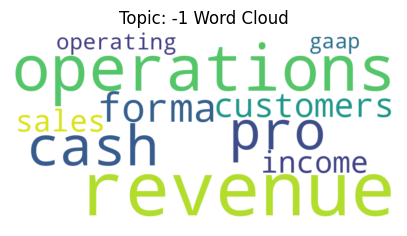


------------------------------------------------------------



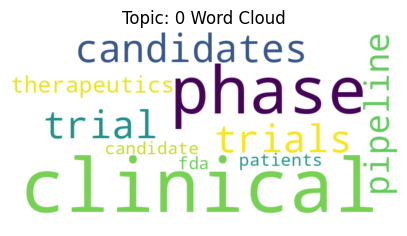


------------------------------------------------------------



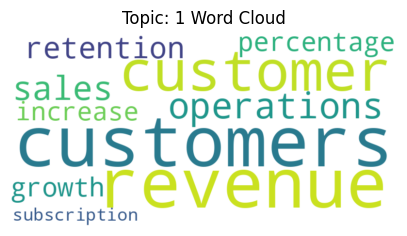


------------------------------------------------------------



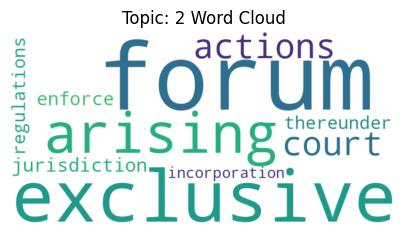


------------------------------------------------------------



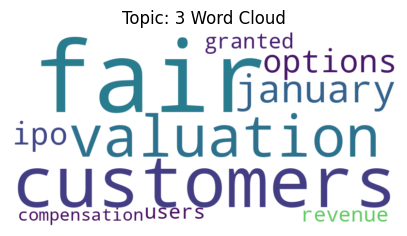


------------------------------------------------------------



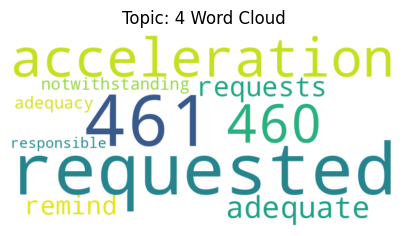


------------------------------------------------------------



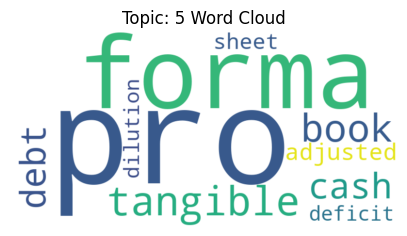


------------------------------------------------------------



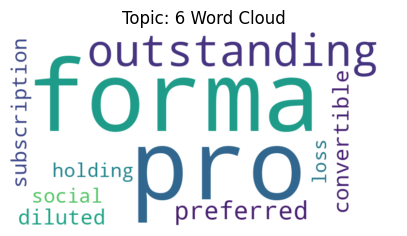


------------------------------------------------------------



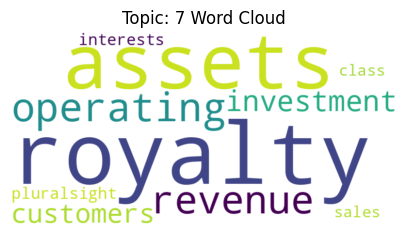


------------------------------------------------------------



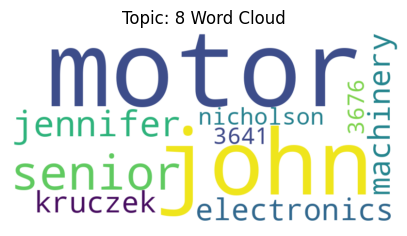


------------------------------------------------------------



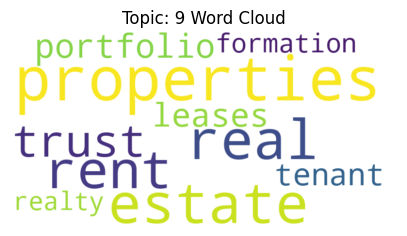


------------------------------------------------------------



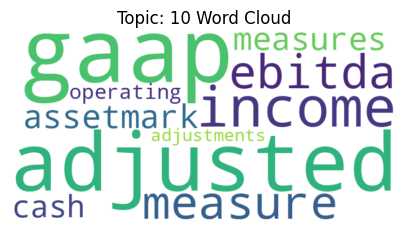


------------------------------------------------------------



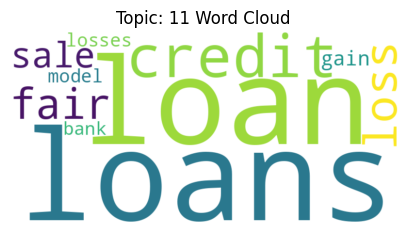


------------------------------------------------------------



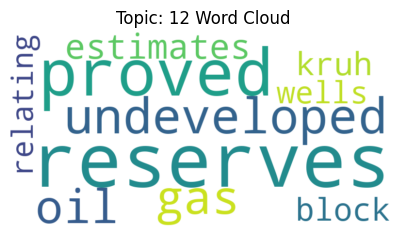


------------------------------------------------------------



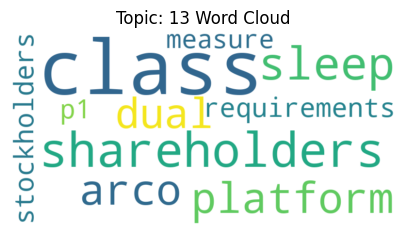


------------------------------------------------------------



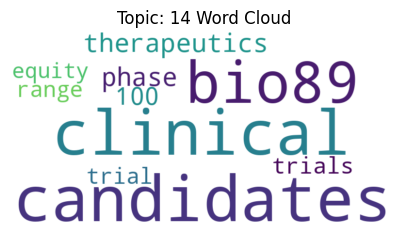


------------------------------------------------------------



In [56]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Function to generate and display word clouds for BERTopic topics
def plot_word_clouds_bertopic(mdl, no_top_words):
    # Get all topics from the BERTopic model along with their words and scores
    topic_words_dict = mdl.get_topics()

    for topic_id, words_with_scores in topic_words_dict.items():
        # Skip the outlier topic, represented by -1 in BERTopic
        #if topic_id == -1:
        #    continue

        # Extract the top words and their scores for the current topic
        # words_with_scores is a list of (word, score) tuples
        topic_words = {word: score for word, score in words_with_scores[:no_top_words]}

        if len(topic_words.keys()) == 0:
            print(f"No words found for topic {topic_id}. Skipping word cloud generation.")
            continue

        # Create a WordCloud object
        wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate_from_frequencies(topic_words)

        # Display the generated image
        plt.figure(figsize=(5, 3))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Topic: {topic_id} Word Cloud')
        plt.show()
        print("\n" + "---"*20 + "\n") # Add a separator for better readability

# Define the number of top words to display in each word cloud
no_top_words = 10 # You can adjust this value as needed

# Call the function with the BERTopic model (`topic_model`) and the desired number of top words
## What do we notice here? :-)
plot_word_clouds_bertopic(topic_model, no_top_words)

## Evaluating BERTopic Models

### The Good News!!

It's even easier to calculate the Cosine Similarity among our Topics (Cao-Juan) becasue we have `topic_embedding_` vectors! Much faster since we can use matrix algebra to speed up the calculations.

Unfortunatley, we cannot calulate Perplexity becuase we are not measuring co-currence the same way as LDA.

But we can still calculate Coherence!

In [57]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

## Copilot
def bertopic_topic_similarity(topic_model):
    """
    Cao-Juan–style metric for BERTopic using topic embeddings.
    Lower score = more diverse, better-separated topics.
    """

    embeddings = topic_model.topic_embeddings_

    sim_matrix = cosine_similarity(embeddings)

    # Take upper triangle without diagonal
    n = sim_matrix.shape[0]
    mean_similarity = sim_matrix[np.triu_indices(n, k=1)].mean()

    return mean_similarity

## Do we expect these topics to be similar?
## Our application is niche, we expect to see smilar topics as measured by the word-embedding space
# SEC letters specific to IPOs,
bertopic_topic_similarity(topic_model=topic_model)

np.float32(0.6901887)

In [58]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.8 MB/s eta 0:00:00


KeyboardInterrupt: 

In [59]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

## Copilot
## Function to Calculate Coherence
def bertopic_coherence(topic_model, docs, coherence="c_v", top_n_words=None):
    vectorizer = topic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()

    tokenized_docs = [analyzer(doc) for doc in docs]
    dictionary = Dictionary(tokenized_docs)
    corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

    topics = topic_model.get_topics()
    topic_words = [
        [word for word, _ in topics[topic_id][:top_n_words]]
        for topic_id in topics if topic_id != -1
    ]

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs if coherence != "u_mass" else None,
        corpus=corpus if coherence == "u_mass" else None,
        dictionary=dictionary,
        coherence=coherence
    )
    return coherence_model.get_coherence()


bertopic_coherence(topic_model=topic_model, docs= text)

np.float64(0.6653421684296668)

## Using the Topic Probabilities

Mission Accopmlished! We have extracted information from the Text ... now what do we do with it?

In [62]:
probabilities

array([[0.01846886, 0.0215404 , 0.01942647, ..., 0.03270806, 0.08126018,
        0.03091774],
       [0.0313252 , 0.06896385, 0.03306942, ..., 0.0540213 , 0.0501662 ,
        0.04149146],
       [0.01488638, 0.0511661 , 0.01497855, ..., 0.03981911, 0.02901867,
        0.02061336],
       ...,
       [0.02627075, 0.07045218, 0.02749331, ..., 0.0509458 , 0.04480799,
        0.0354113 ],
       [0.38973252, 0.02465111, 0.04155108, ..., 0.02550775, 0.03297205,
        0.06160907],
       [0.01509463, 0.43688778, 0.0151373 , ..., 0.02982707, 0.02343972,
        0.01915543]])

In [64]:
## Put back into data frame
## First, we need to pull in the Topic Associations of each Letter
## list of columns names; one for eacg discoverd topic
topics_cols = [f"Topic_{i}" for i in range(len(probabilities[0]))]

## Then create Data FRame from numpy, schema = topic_cols
prob_df = pl.from_numpy(probabilities, schema = topics_cols)

## Then Concat; how= 'horizontal'
df_content_probs = pl.concat([df_content, prob_df], how = 'horizontal')

## And we'll add the topic label - not
df_content_probs

file_name,body_text,char_length,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10,Topic_11,Topic_12,Topic_13,Topic_14
str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2020-10-13 04_00_00_0001422930…",""" Please revise page F-25 to di…",4206,0.018469,0.02154,0.019426,0.047498,0.025178,0.076719,0.393255,0.034892,0.026466,0.037613,0.038858,0.028142,0.032708,0.08126,0.030918
"""2019-04-24 04_00_00_0001178697…","""1. Disclose the number of shar…",2228,0.031325,0.068964,0.033069,0.056228,0.066771,0.046011,0.044749,0.066513,0.072967,0.075958,0.05305,0.07006,0.054021,0.050166,0.041491
"""2018-08-14 04_00_00_0001670592…","""Operating activities, page 60 …",6909,0.014886,0.051166,0.014979,0.032895,0.024056,0.040589,0.030661,0.028565,0.027812,0.036528,0.059508,0.041384,0.039819,0.029019,0.020613
"""2019-03-13 04_00_00_0001517413…",""" Fastly, Inc. March 13, 2019 …",5547,0.025586,0.117206,0.025148,0.056302,0.041214,0.050414,0.042629,0.049302,0.045703,0.052886,0.062768,0.065312,0.047675,0.046375,0.036332
"""2018-10-29 04_00_00_0001655210…",""" 1. We note the disclosure yo…",3275,0.030266,0.046892,0.028045,0.040792,0.052281,0.031764,0.032279,0.056715,0.062888,0.052265,0.036645,0.054405,0.036635,0.037759,0.034697
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2018-05-30 04_00_00_0001728951…",""" Office of Real Estate and 1.…",1387,2.1487e-308,2.8821e-308,2.9210e-308,3.1646e-308,4.7995e-308,3.7555e-308,4.0600e-308,6.4029e-308,6.3807e-308,1.0,4.0110e-308,4.9322e-308,6.3797e-308,4.3012e-308,2.6472e-308
"""2018-09-14 04_00_00_0001576280…",""" Guardant Health, Inc. Septemb…",1535,0.021538,0.018462,0.027437,0.024261,0.602526,0.017488,0.020201,0.036169,0.052402,0.030251,0.018034,0.022143,0.021218,0.022556,0.024346
"""2019-10-16 04_00_00_0001786431…","""October 16, 2019 Page 2 Office…",758,0.026271,0.070452,0.027493,0.048548,0.053521,0.0448,0.041639,0.056545,0.061578,0.067506,0.054734,0.070504,0.050946,0.044808,0.035411


In [ ]:
## Let's pull out the CIK and file_date again
topic_df = (

)
topic_df.head()

In [ ]:
## Are any Topics more common in any year?



In [ ]:
## Remember we have multiple letters for each CIk?
## What should we do?
## Depends on our analysis...


In [ ]:
## Fow now, let's just take the average topic association of all a CIK's letters


### Using Probabilities as Topic Associations

If trained and tuned well, these Topic Probabilities can be intepreted as topic `associations`, measuring how heavily a document is associated with the topic.

That is a fairly LARGE condition, however, that the model is trained and tuned well, so be cautions (check and verify your model well!)

[Link to IPO Dataset](https://drive.google.com/file/d/1iSHYanrVtJyx-UCbg3UwVMzPYoOFSv8K/view?usp=sharing)

In [ ]:
df_ipo = pl.read_ipc("Data/ex3_ipo_data.feather")
df_ipo

In [ ]:
## Merge on CIK and cik; .join
df_to_model = pl.join()

df_to_model

In [ ]:
import statsmodels.api as sm
import pandas as pd ## Stats models does not play nice with Polars ...

dep_var = 'underpricing'

X = df_to_model.drop(pl.col(['Filing_Date','Issue_Date','Form','cik','IPO_Price','underpricing','ind_code'])).to_pandas()
X = pd.get_dummies(X, columns=['Issue_Year'], dtype = int, drop_first=True)
y = df_to_model.select(col(dep_var)).to_pandas()
X1 = sm.add_constant(X)

model = sm.OLS(y, X1)
fit = model.fit()
print(fit.summary())

## Training Multiple BERTopic Models

Tuning the collection of hyperparameters above (`n_neighbors`, `min_cluster_size`, etc) is VERY time expensive.


As time allows:
- BERTopic is VERY malleable, but the convenience of the above approach is VERY computationally expensive.
- We don't NEED to embed the text more than once.
- MUCH faster to only run UMAP once for each of its configurations, and only one HDBSCAN for each UMAPxHDBSCAN configuration.
- Only then, paralelize the final BERTopic assembly.
  -  I had a conversation with Copilot to construct this, which we can do together as time allows.

In [ ]:
# Step 1 - Retrieve embeddings
## This is a pretrained Word Embedding Model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(
    text,
    show_progress_bar=True
)

## Careful with your file names if you
## plan to create multiple versions.
with open('letters_embedding.pkl', 'wb') as file:
    pk.dump(embedding_model, file)

In [ ]:
## Define parameter space
## Notice all of these paramters are of UMAP, HDBSCAN, and the final Representation.
param_grid = {'embedding_model': [None], ## WE NEED to delcare this as NONE to pass our trained one in later
              'n_neighbors': [10,15,20],
              'n_components': [5, 10],
              'min_dist': [0.0, 0.1],
              'min_cluster_size': [10, 20, 30],
              #########
              'min_df': [0.01],# [0.1, 0.05, 0.01],
              'max_df': [0.95], #[0.99, 0.95, 0.90],
              'representation_model': [None], #[None, KeyBERTInspired()],
              'verbose': [False]}

In [ ]:
from sklearn.model_selection import ParameterGrid
from tqdm.notebook import tqdm

results = []
models = []

## We'll just do it one at a time
## To speed this up EVEN further, we could only compute each set of these paramters ONCE and keep track of it
## We can also paralize these computations.
for params in tqdm(ParameterGrid(param_grid)):
### EVERYTHING FROM BEFORE
### STEP 2 - ALL STEPS TOGETHER


### Now, fit the model, score it, and append to lists

results.append({**params, "score": scores})



In [ ]:
## SAVE Results and Models to disk!!


### A Pre-Computed Copy of the Results

[Link to Results.](https://drive.google.com/file/d/1CdNOudlhWK_TZWtIyu5tiz8DTiZADXKX/view?usp=sharing)

In [ ]:
with open("berttopic_search_2006.pkl", 'rb') as file:
  file_contents = pk.load(file)
  results = file_contents['results']
  models = file_contents['models']

In [ ]:
## And We can Further Evaluate!

## Let's put all the scores in a DataFrame
## First as lists
scores = []
for i in results:
    scores.append(i['score'])

## Then as a Dataframe
df_scores = pl.DataFrame(scores)
df_scores = (
    df_scores
    .with_row_index()
)
df_scores

In [ ]:
## PLOT!
import matplotlib.pyplot as plt

# Extract data
x = df_scores["similarity"].to_numpy()
y = df_scores["coherence"].to_numpy()
model_indexes = df_scores['index']
## Label the number of topics
labels = [len(models[i].topic_labels_.keys())-1 for i in model_indexes]

plt.scatter(x, y)

# Label each point with the index
for xi, yi, lbl in zip(x, y, labels):
    plt.text(
        xi, yi, str(lbl),
        fontsize=12,
        ha="right",
        va="bottom",
    )

plt.xlabel("Similarity")
plt.ylabel("Coherence")
plt.title("Similarity vs Coherence")
plt.show()

In [ ]:
## Which configuration looks good?
## Let's retrieve it!

In [ ]:
## Word Clouds of that Model!